# larcform1 progress report — supercooled Arctic liquid in the ClimaAtmos SCM

**Date:** 2026-07-05 · **Case:** Larcform1 (Pithan et al. 2016 Arctic winter single-column intercomparison) · **Model:** ClimaAtmos.jl 1M prognostic-EDMFx column, slab surface @ 250 K · **Reference:** EC-Earth from the Pithan 2016 intercomparison dataset

## Executive summary

1. **Problem.** Our ClimaAtmos implementation of the Larcform1 case produced *identically zero* supercooled cloud liquid (`clw`), where the reference model (EC-Earth) sustains a mixed-phase cloud for its first two days.
2. **Root cause found and confirmed** (clw sensitivity experiment, 12 variations): the default `ConstantTimescale` vapor→cloud-ice deposition is an *unbounded* Wegener–Bergeron–Findeisen (WBF) sink — with a 100 s timescale and no dependence on ice mass or ice-nucleating-particle (INP) availability, it pins vapor at ice saturation so the liquid-condensation gate never opens. Switching to `cloud_ice_formation: "TemperatureDependent"` (Frostenberg 2023 INP-limited deposition, variation v10) restores the cloud at the right height, temperature, and onset time.
3. **A 16–40× faster forward model was validated** (SCM speed tests, s1–s13): the dominant cost of the original config was 10-minute-cadence debugging diagnostics (~90% of runtime), not physics; a convergence ladder showed the 100-level stretched grid (10 m at the surface, 5 km top) is the *converged* answer; the adopted calibration config (s11) solves 2 simulated days in ~42 s and preserves the v1-physics discriminator (clw still exactly zero — the WBF failure is physics, not resolution).
4. **Six microphysics parameters were calibrated** with unscented Kalman inversion (UKI, 6 iterations × 13 members, 54 min total) against EC-Earth day-2 clw/cli profiles. This required un-deadening the Frostenberg 2023 `a`/`b` INP-curve coefficients, which ClimaParams defines but CloudMicrophysics (v0.36 *and* upstream main) never reads — fixed via a one-function vendored patch. Day-2 misfit fell from χ²/dim 12.8 to **1.73**.
5. **Out-of-sample verification passed.** In 5-day runs, the calibrated model reproduces EC-Earth's *entire cloud life cycle* — including glaciation at hour 54 (EC-Earth: 51) that was never part of the training objective; the uncalibrated baseline holds 5× too much liquid and glaciates a day late.
6. **Data discovery en route:** the EC-Earth reference record is 20 days (481 hourly steps), not 2 as all pre-2026-07-05 analyses assumed — and EC-Earth's own cloud glaciates on day 3. The day-2 calibration window targets the transient mixed-phase phase; neither model reproduces the multi-day persistence of *observed* Arctic clouds, which is now a documented physics question separate from tuning.

**Where things stand:** calibration validated, final parameter means adopted, all work committed (`experiments/clw calibration`, vendored `CloudMicrophysics.jl` patch, experiment write-ups); the ClimaAtmos fork branch `jy/coldslab` is pushed.


In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import tomllib
import warnings
warnings.filterwarnings("ignore")

ROOT = Path("/home/jeff/larcform1-experiments")
EC_PATH = ROOT / "Pithan 2016 Intercomparison Data" / "EC-Earth.nc"
SENS = ROOT / "experiments/clw sensitivity experiments/output/pithan_format"
CAL = ROOT / "experiments/clw calibration"
V5D = CAL / "output/verify5d"
FIGDIR = ROOT / "experiments/progress report/figures"
FIGDIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.constrained_layout.use": True,
})
C = {"EC-Earth": "#222222", "calibrated": "#d95f02", "baseline": "#7570b3",
     "v10": "#1b9e77", "other": "#999999"}

ec = xr.load_dataset(EC_PATH, decode_times=False).squeeze()
ec_lev = [d for d in ec["clw"].dims if d != "time"][0]
ec_h = np.arange(ec.sizes["time"])          # hourly steps

def load_pithan(name):
    """Converted (EC-Earth-vocabulary) sensitivity-run file."""
    return xr.load_dataset(SENS / f"{name}.nc").squeeze()

def load_raw(run_dir):
    """Raw ClimaAtmos 1h-average diagnostics (calibration/verification runs)."""
    d = Path(run_dir) / "output_active"
    return {v: xr.load_dataset(d / f"{v}_1h_average.nc")[v].squeeze()
            for v in ["clw", "cli", "pfull", "lwp", "clivi"]}

print(f"EC-Earth record: {ec.sizes['time']} hourly steps = {ec.sizes['time']/24:.1f} days")

EC-Earth record: 481 hourly steps = 20.0 days


## 1. The target: EC-Earth's Larcform1 cloud — and what its full record shows

The Larcform1 case is a polar-night, single-column Arctic experiment: a 250 K atmosphere over a freezing surface, no sun, physics left to build a cloud. Among the Pithan 2016 intercomparison models, EC-Earth is the closest match to our setup (it, too, runs "no snow, fixed ice" — Table 3) and the one whose modest liquid water path (day-2 mean clwvi ≈ 0.038 kg/m², matching Table 5's 0.037) sits at the *low*, observation-adjacent end of the intercomparison spread (ECHAM-HAM: 0.39; the paper notes model LWPs generally run high vs SHEBA observations). That makes it a good calibration target.

A caveat discovered only on 2026-07-05: `EC-Earth.nc` spans **20 days**, not 2 — every earlier analysis sliced the first 48 h. The full record (below) shows the mixed-phase cloud is *transient in EC-Earth too*: liquid collapses on day 3 (WBF glaciation), ice peaks on day 4 and slowly sediments away. The day-2 calibration window therefore targets the transient mixed-phase phase, and "persistence" comparisons only apply within days 1–2.

**Scope note on the surface:** we use a slab ocean (heat capacity, no ice/snow conduction), standing in for the protocol's interactive 1 m ice + 0.1 m snow. The paper's clear-state result (surface-based inversions, which hinge on snow insulation) is out of scope for this surface; only the cloudy state — our target — is meaningfully comparable, and EC-Earth shares that limitation.

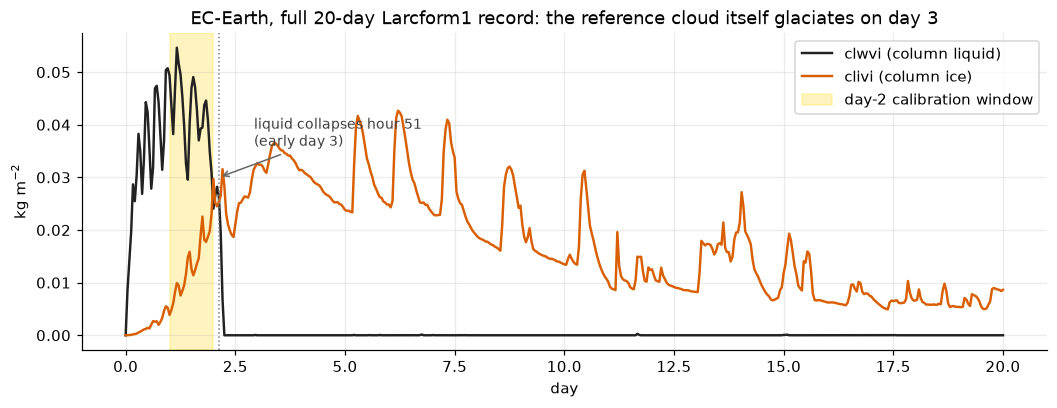

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 3.6))
d = ec_h / 24
ax.plot(d, ec["clwvi"].values, color=C["EC-Earth"], lw=1.6, label="clwvi (column liquid)")
ax.plot(d, ec["clivi"].values, color=C["calibrated"], lw=1.6, label="clivi (column ice)")
ax.axvspan(1, 2, color="gold", alpha=0.25, label="day-2 calibration window")
glac_h = int(np.where(ec["clw"].max(dim=ec_lev).values > 1e-4)[0].max())
ax.axvline(glac_h / 24, color="0.5", ls=":", lw=1)
ax.annotate(f"liquid collapses hour {glac_h}\n(early day 3)", (glac_h / 24, 0.030),
            xytext=(glac_h / 24 + 0.8, 0.036),
            arrowprops=dict(arrowstyle="->", color="0.4"), fontsize=9, color="0.25")
ax.set(xlabel="day", ylabel="kg m$^{-2}$",
       title="EC-Earth, full 20-day Larcform1 record: the reference cloud itself glaciates on day 3")
ax.legend(loc="upper right")
fig.savefig(FIGDIR / "fig1_ecearth_20day_record.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Root cause: unbounded WBF in `ConstantTimescale` ice deposition

**The sensitivity screen** (`experiments/clw sensitivity experiments/`, 12 single-change variations, 2-day runs) localized the liquid killer by elimination and then confirmed the mechanism in the CloudMicrophysics source:

| variation | change vs base | max clw (kg/kg) | outcome |
|---|---|---|---|
| v1_base | none | **0.0 exactly** | fail — clw identically zero all run |
| v2_0M | 0M microphysics | 1.4e-4 | marginal — equilibrium partition, no kinetic WBF |
| v3_2M | 2M microphysics | — | setup crash (2M + SGS quadrature unimplemented) |
| v4_cloudonly | all precip processes off | 0.0 | fail → precipitation exonerated; cli piles up unbounded → deposition is the killer |
| v5–v7 | τ_subl 10→1000 | 0.0 | fail |
| v8 | τ_subl = 10 000 | 4.8e-4 | transient burst, then killed by the separate snow-deposition vapor sink |
| v9 | τ_cond = 10 | 0.0 | fail — the liquid gate never opens, faster condensation can't help |
| **v10** | `cloud_ice_formation: "TemperatureDependent"` | **5.1e-4** | **pass — the fix**; liquid + ice + snow at EC-Earth magnitudes |
| v11 | ice deposition deleted | 5.1e-4 | pass for liquid but clivi ≡ 0 → deposition is the *only* ice-initiation path here |
| v12 | τ_subl = 10⁹ (constant) | 5.1e-4 | liquid ≈ v10 but ice ~200× low → no constant τ can emulate the INP-limited scheme |

**Mechanism.** In the 1M scheme, liquid condenses only when vapor exceeds *liquid* saturation, but the default ice scheme deposits vapor toward *ice* saturation on a fixed 100 s timescale with no dependence on existing ice mass or INP availability. Below freezing, ice saturation < liquid saturation always, so vapor is pinned below the liquid gate: WBF with the physical brake (finite ice surface area) removed → clw ≡ 0. The `TemperatureDependent` alternative computes the deposition timescale from diffusional growth onto INP-nucleated crystals (Frostenberg 2023 Arctic INP climatology). At this cloud's −10 °C there are ~1 INP m⁻³ — deposition starts ~10⁷× slower, liquid wins the vapor competition, and ice then bootstraps as crystals grow (v11/v12 confirm the *feedback*, not the timescale value, is what matters).

This finding was later hardened by the speed-test control **s13**: v1 physics on a converged 10 m grid still gives clw = 0.0 at every level and hour — no amount of vertical resolution rescues the liquid. (The literature counterpoint is instructive: Pithan 2016's WRF-200l lost its liquid at *high* resolution via 1.2 m-level frost drying — a different mechanism our 10 m grids don't exhibit.)

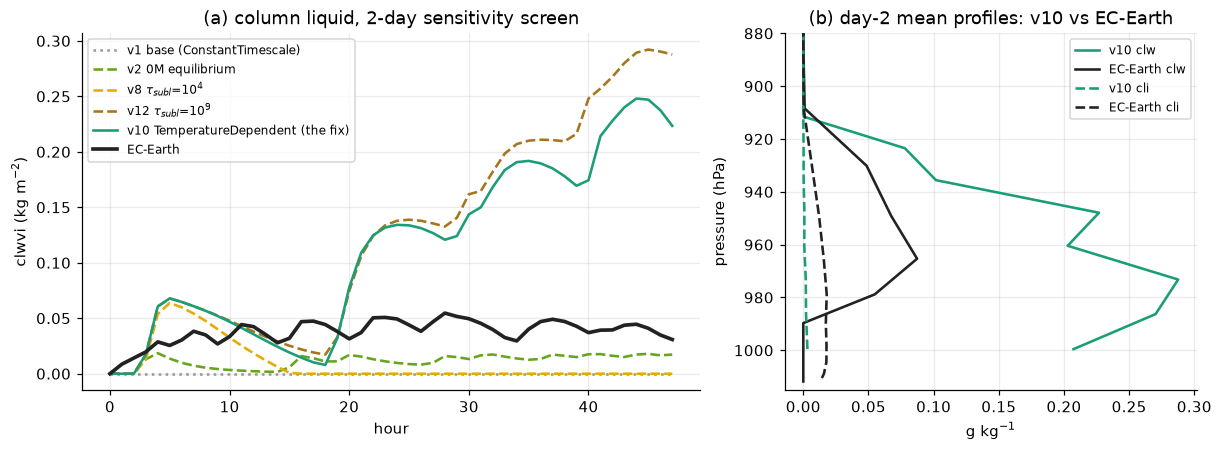

v10 restores the supercooled layer at the right height; remaining gaps are amount-type (too much column liquid, too little ice) — i.e. calibration targets.


In [11]:
runs = [("v1_base", "v1 base (ConstantTimescale)", C["other"], ":"),
        ("v2_0M", "v2 0M equilibrium", "#66a61e", "--"),
        ("v8_subltime10000", "v8 $\\tau_{subl}$=10$^4$", "#e6ab02", "--"),
        ("v12_subltime1e9", "v12 $\\tau_{subl}$=10$^9$", "#a6761d", "--"),
        ("v10_tdepice", "v10 TemperatureDependent (the fix)", C["v10"], "-")]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.5, 1]})
for name, lab, col, ls in runs:
    ds = load_pithan(name)
    a1.plot(np.arange(ds.sizes["time"]), ds["clwvi"].values, color=col, ls=ls, lw=1.7, label=lab)
a1.plot(ec_h[:48], ec["clwvi"].values[:48], color=C["EC-Earth"], lw=2.4, label="EC-Earth")
a1.set(xlabel="hour", ylabel="clwvi (kg m$^{-2}$)", title="(a) column liquid, 2-day sensitivity screen")
a1.legend(fontsize=8)

v10 = load_pithan("v10_tdepice")
p10 = v10["p"].isel(time=slice(24, 48)).mean("time").values / 100
ecp = ec["p"].isel(time=slice(24, 48)).mean("time").values / 100
for var, ls in [("clw", "-"), ("cli", "--")]:
    a2.plot(v10[var].isel(time=slice(24, 48)).mean("time").values * 1e3, p10,
            color=C["v10"], ls=ls, lw=1.7, label=f"v10 {var}")
    a2.plot(ec[var].isel(time=slice(24, 48)).mean("time").values * 1e3, ecp,
            color=C["EC-Earth"], ls=ls, lw=1.7, label=f"EC-Earth {var}")
a2.set(ylim=(1015, 880), xlabel="g kg$^{-1}$", ylabel="pressure (hPa)",
       title="(b) day-2 mean profiles: v10 vs EC-Earth")
a2.legend(fontsize=8)
fig.savefig(FIGDIR / "fig2_sensitivity_screen.png", dpi=150, bbox_inches="tight")
plt.show()
print("v10 restores the supercooled layer at the right height; remaining gaps are amount-type "
      "(too much column liquid, too little ice) — i.e. calibration targets.")

## 3. A forward model fast enough to calibrate (SCM speed tests)

Calibration needs ~80+ forward runs; the original config took ~11–12 min each. The speed-test experiment (`experiments/scm speed tests/`, runs s1–s13) found:

- **Diagnostics, not physics, dominated runtime.** The 54-variable, 10-minute-cadence EDMF/microphysics-tendency groups (accumulated averages, computed every timestep) consumed ~90% of the original runtime. Trimming to the 20-variable converter set alone brought a full-grid run to 26.5 s.
- **The stretched grid is the converged answer, not a landmine.** A uniform-resolution ladder (167 m → 100 → 50 → 25 → 10 m) marches monotonically toward the tanh-stretched grid's behavior (onset h5→h0, persistence 40→48 of 48 h). The 100-stretched-level grid (s10) matches the 500-level uniform 10 m anchor (s9) at ⅓ its cost. The config's z-banding warning did not materialize under v10 physics; onset/persistence gaps vs EC-Earth were a resolution artifact, not microphysics.
- **dt_rad 30 min is safe** (polar night, LW only): rlds shifts −0.4 W/m²; 1 h was marginal and rejected.
- **s13 control:** the light grid preserves the v1-physics discriminator (clw exactly 0.0) — see §2.

**Adopted calibration config "s11":** 5 km top, 100 stretched levels (10 m at the surface), dt 30 s, dt_rad 30 min, minimal diagnostics — **42 s solve** for 2 simulated days (~16× vs original; ~40× for the pre-convergence candidate). The validated diagnostics/dt_rad trims were applied to the base ClimaAtmos config (branch `jy/coldslab`).

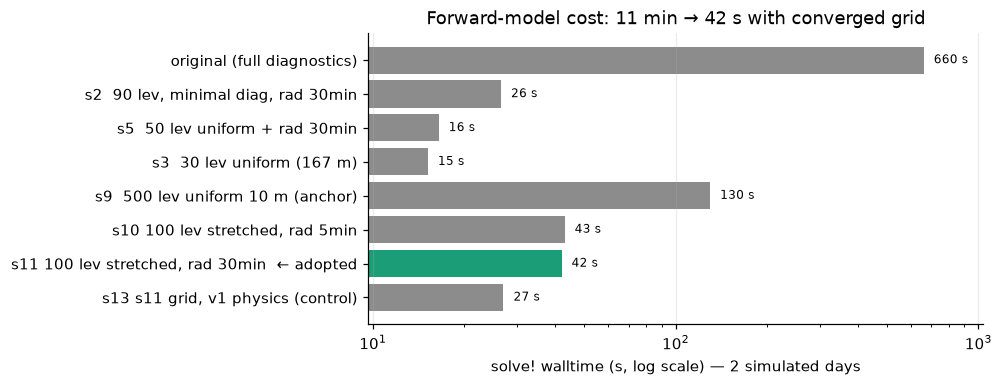

Convergence ladder (uniform grids march toward the stretched answer):


,run,onset (h),hrs clw>1e-4 (of 48),max clw (1e-4 kg/kg)
0,s3 167 m,5,40,4.84
1,v10 100 m,3,43,5.11
2,s7 50 m,2,45,5.37
3,s8 25 m,1,47,5.01
4,s9 10 m,0,48,3.98
5,s4 stretch/30,0,48,4.53
6,s10 stretch/100,0,48,3.97
7,EC-Earth,1,47,6.81


In [12]:
times = [("original (full diagnostics)", 660, "0.55"), ("s2  90 lev, minimal diag, rad 30min", 26.5, "0.55"),
         ("s5  50 lev uniform + rad 30min", 16.5, "0.55"), ("s3  30 lev uniform (167 m)", 15.2, "0.55"),
         ("s9  500 lev uniform 10 m (anchor)", 130, "0.55"), ("s10 100 lev stretched, rad 5min", 43, "0.55"),
         ("s11 100 lev stretched, rad 30min  ← adopted", 42, C["v10"]), ("s13 s11 grid, v1 physics (control)", 27, "0.55")]
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.barh([t[0] for t in times][::-1], [t[1] for t in times][::-1],
        color=[t[2] for t in times][::-1])
ax.set_xscale("log"); ax.set_xlabel("solve! walltime (s, log scale) — 2 simulated days")
ax.set_title("Forward-model cost: 11 min → 42 s with converged grid")
for i, (lab, t, c) in enumerate(times[::-1]):
    ax.text(t * 1.08, i, f"{t:.0f} s", va="center", fontsize=8)
ax.margins(x=0.12); ax.grid(axis="y", alpha=0)
fig.savefig(FIGDIR / "fig3_speedtest_walltime.png", dpi=150, bbox_inches="tight")
plt.show()

ladder = pd.DataFrame({
    "run": ["s3 167 m", "v10 100 m", "s7 50 m", "s8 25 m", "s9 10 m", "s4 stretch/30", "s10 stretch/100", "EC-Earth"],
    "onset (h)": [5, 3, 2, 1, 0, 0, 0, 1],
    "hrs clw>1e-4 (of 48)": [40, 43, 45, 47, 48, 48, 48, 47],
    "max clw (1e-4 kg/kg)": [4.84, 5.11, 5.37, 5.01, 3.98, 4.53, 3.97, 6.81],
})
print("Convergence ladder (uniform grids march toward the stretched answer):")
ladder

## 4. Calibration: 6-parameter UKI against EC-Earth day-2 profiles

**Setup** (`experiments/clw calibration/`): ClimaCalibrate + EnsembleKalmanProcesses `TransformUnscented` (UKI, `impose_prior=true`) → 13 deterministic sigma-point members per iteration, run sequentially in one Julia process (JIT paid once; ~38 s/member, ~8.2 min/iteration, 6 iterations + fixed cost = **54 min measured**).

**Observations:** EC-Earth day-2 (hours 25–48) time-mean clw and cli profiles, interpolated to 10 pressure levels (995→905 hPa), transformed `log10(q + 10⁻⁷)`; 20-dim observation vector, diagonal noise σ = 0.3 log₁₀ units (≈ factor-2 per level). Target cross-validated against Pithan 2016 Table 5.

**The dead-knob discovery.** The headline parameters — Frostenberg 2023 INP-curve coefficients `a`, `b` — turned out to be *dead* in CloudMicrophysics: ClimaParams defines them, the parameter struct stores them, but `INP_concentration_mean` hardcodes the curve (registered v0.36 **and** upstream main, checked 2026-07-05). Calibrating them would have been a silent no-op. Fixed with a one-function vendored patch (`CloudMicrophysics.jl/` at repo root, wired into only the calibration environment): the INP concentration becomes `9·log(−b·T_C/10) − log(a)` per the paper's Eq. (1), reducing exactly to stock at a = b = 1. Verified analytically and via sigma-point smoke tests before the full run. *Candidate upstream contribution.*

**Parameters and result** (final constrained means, adopted):

| parameter | prior center | final | physics of the move |
|---|---|---|---|
| `Frostenberg2023_a_coefficient` | 1 | **0.254** | ≈4× more INPs |
| `Frostenberg2023_b_coefficient` | 1 | **1.194** | ≈×4.8 INP concentration, cold-ward tilt |
| `snow_autoconversion_timescale` | 100 s | **832 s** | cloud ice retained ~8× longer (was draining to snow in ~100 s → clivi 7× low) |
| `clw autoconversion threshold` | 5e-4 | **3.77e-4** | rain drain now active (model clw peaks ~4.2e-4 — the default threshold meant rain *never* formed → clwvi 3.5× high) |
| `sublimation_deposition_timescale` | 100 s | 66.6 s | minor |
| `condensation_evaporation_timescale` | 100 s | 101.1 s | untouched |

The moves are physically coherent: more ice production **and** slower ice-to-snow drain attack the ice deficit; the opened rain drain bleeds the liquid excess.

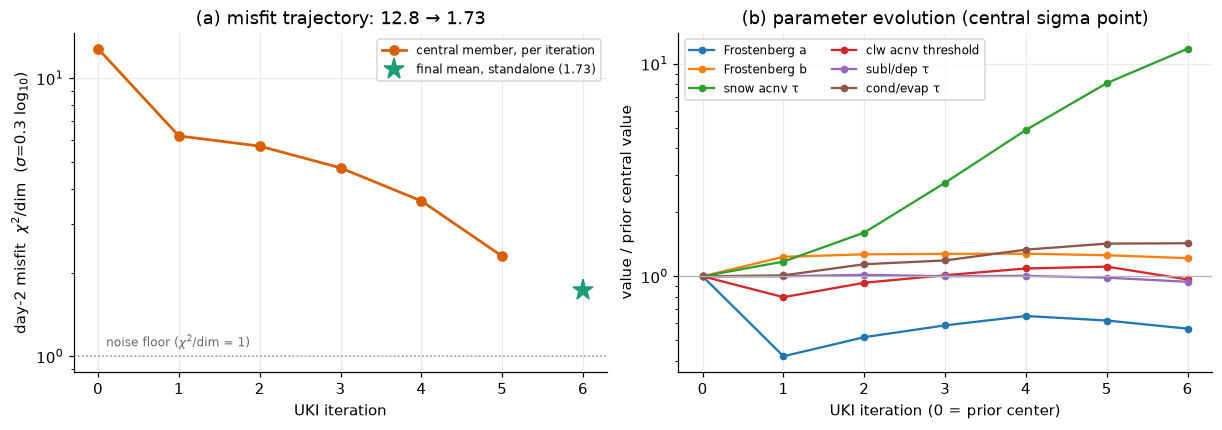

Misfit still descending at iteration 6 → more iterations (or a revisited noise model) could tighten further.


In [13]:
PARAMS = ["Frostenberg2023_a_coefficient", "Frostenberg2023_b_coefficient",
          "snow_autoconversion_timescale", "cloud_liquid_water_specific_humidity_autoconversion_threshold",
          "sublimation_deposition_timescale", "condensation_evaporation_timescale"]
SHORT = ["Frostenberg a", "Frostenberg b", "snow acnv τ", "clw acnv threshold", "subl/dep τ", "cond/evap τ"]

traj = []
for i in range(1, 8):
    with open(CAL / f"output/uki_1/iteration_{i:03d}/member_001/parameters.toml", "rb") as fh:
        t = tomllib.load(fh)
    traj.append([t[p]["value"] for p in PARAMS])
traj = np.array(traj)                      # (7 iters, 6 params); iter 1 = prior central point

misfit = [12.77, 6.20, 5.70, 4.76, 3.62, 2.29]   # chi2/dim, central member per iteration (see md)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.plot(range(6), misfit, "o-", color=C["calibrated"], lw=1.8, label="central member, per iteration")
a1.plot(6, 1.73, "*", ms=14, color=C["v10"], label="final mean, standalone (1.73)")
a1.axhline(1, color="0.6", ls=":", lw=1); a1.text(0.1, 1.08, "noise floor ($\\chi^2$/dim = 1)", fontsize=8, color="0.4")
a1.set(xlabel="UKI iteration", ylabel="day-2 misfit  $\\chi^2$/dim  ($\\sigma$=0.3 log$_{10}$)",
       title="(a) misfit trajectory: 12.8 → 1.73", yscale="log")
a1.legend(fontsize=8)

for j, (p, s) in enumerate(zip(PARAMS, SHORT)):
    a2.plot(range(7), traj[:, j] / traj[0, j], "o-", ms=4, lw=1.5, label=s)
a2.axhline(1, color="0.7", lw=0.8)
a2.set(xlabel="UKI iteration (0 = prior center)", ylabel="value / prior central value", yscale="log",
       title="(b) parameter evolution (central sigma point)")
a2.legend(fontsize=8, ncols=2)
fig.savefig(FIGDIR / "fig4_uki_misfit_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()
print("Misfit still descending at iteration 6 → more iterations (or a revisited noise model) could tighten further.")

## 5. The decisive test: 5-day out-of-sample verification

The calibration only ever saw a day-2 snapshot — and it boosted ice production ~4–5×, raising an obvious worry: does the calibrated model now glaciate *too readily* after day 2? Three standalone 5-day runs answer this (final mean = "calibrated"; iteration-6 mean; stock-v10 "baseline").

**The calibrated model reproduces EC-Earth's full cloud life cycle**: liquid buildup at the right magnitude on day 1, glaciation on day 3 within 3 hours of EC-Earth's, ice-only aftermath. The glaciation timing was never in the objective — it *emerged* from the calibrated ice physics, which is strong evidence the parameters capture mechanism rather than curve-fit. The baseline, by contrast, carries 5× too much liquid through day 2 and glaciates a day late. (A corollary: stock v10's celebrated "48/48-hour persistence" in the 2-day screen was a record-length illusion — it also glaciates, on day 4.)

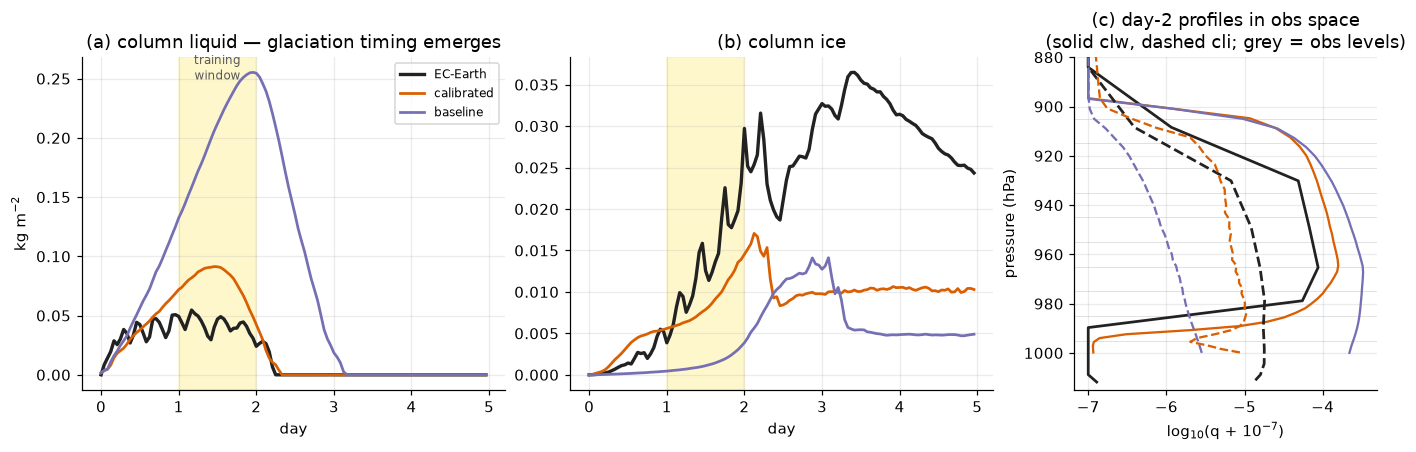

In [14]:
runs = {"calibrated": load_raw(V5D / "calibrated"), "baseline": load_raw(V5D / "baseline"),
        "iter6mean": load_raw(V5D / "iter6mean")}

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4), gridspec_kw={"width_ratios": [1.4, 1.4, 1]})
a1, a2, a3 = axes
h5 = np.arange(120)
a1.plot(h5 / 24, ec["clwvi"].values[:120], color=C["EC-Earth"], lw=2.2, label="EC-Earth")
a2.plot(h5 / 24, ec["clivi"].values[:120], color=C["EC-Earth"], lw=2.2, label="EC-Earth")
for name in ["calibrated", "baseline"]:
    r = runs[name]
    a1.plot(h5 / 24, r["lwp"].values[:120], color=C[name], lw=1.8, label=name)
    a2.plot(h5 / 24, r["clivi"].values[:120], color=C[name], lw=1.8, label=name)
for ax in (a1, a2):
    ax.axvspan(1, 2, color="gold", alpha=0.2)
    ax.set_xlabel("day")
a1.set(ylabel="kg m$^{-2}$", title="(a) column liquid — glaciation timing emerges")
a2.set(title="(b) column ice")
a1.legend(fontsize=8); a1.text(1.5, a1.get_ylim()[1]*0.93, "training\nwindow", ha="center", fontsize=8, color="0.35")

ecp = ec["p"].isel(time=slice(24, 48)).mean("time").values / 100
for var, ls in [("clw", "-"), ("cli", "--")]:
    a3.plot(np.log10(np.maximum(ec[var].isel(time=slice(24, 48)).mean("time").values, 0) + 1e-7), ecp,
            color=C["EC-Earth"], ls=ls, lw=1.8)
    for name in ["calibrated", "baseline"]:
        r = runs[name]
        p = r["pfull"].isel(time=slice(24, 48)).mean("time").values / 100
        a3.plot(np.log10(np.maximum(r[var].isel(time=slice(24, 48)).mean("time").values, 0) + 1e-7), p,
                color=C[name], ls=ls, lw=1.5)
for lev in np.arange(995.0, 904.9, -10.0):
    a3.axhline(lev, color="0.85", lw=0.5, zorder=0)
a3.set(ylim=(1015, 880), xlabel="log$_{10}$(q + 10$^{-7}$)", ylabel="pressure (hPa)",
       title="(c) day-2 profiles in obs space\n(solid clw, dashed cli; grey = obs levels)")
fig.savefig(FIGDIR / "fig5_5day_verification.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# Verification scorecard — computed live with the same transform as the Julia observation map.
# (Recorded pitfall: an earlier ad-hoc rescoring used positional slicing + clamping interp and got
#  bogus chi2; this cell replicates the verified scorer, which matches the authoritative Julia
#  g_vector path bit-for-bit on these runs.)
P = np.arange(995.0, 904.9, -10.0)
def gvec(clw, cli, p):
    o = np.argsort(p)
    return np.concatenate([np.log10(np.interp(P, p[o], clw[o]) + 1e-7),
                           np.log10(np.interp(P, p[o], cli[o]) + 1e-7)])
y = gvec(ec["clw"].isel(time=slice(24, 48)).mean("time").values,
         ec["cli"].isel(time=slice(24, 48)).mean("time").values, ecp)

rows = []
ec_maxclw = ec["clw"].max(dim=ec_lev).values
rows.append({"run": "EC-Earth", "day-2 chi2/dim": 0.0,
             "day-2 clwvi": ec["clwvi"].values[24:48].mean(),
             "last liquid hour": int(np.where(ec_maxclw > 1e-4)[0].max()),
             "day-4/5 clivi": ec["clivi"].values[72:120].mean()})
for name in ["calibrated", "iter6mean", "baseline"]:
    r = runs[name]
    lev = [d for d in r["clw"].dims if d != "time"][0]
    p = r["pfull"].isel(time=slice(24, 48)).mean("time").values / 100
    g = gvec(r["clw"].isel(time=slice(24, 48)).mean("time").values,
             r["cli"].isel(time=slice(24, 48)).mean("time").values, p)
    mx = r["clw"].max(dim=lev).values
    rows.append({"run": name, "day-2 chi2/dim": np.mean(((g - y) / 0.3) ** 2),
                 "day-2 clwvi": r["lwp"].values[24:48].mean(),
                 "last liquid hour": int(np.where(mx > 1e-4)[0].max()),
                 "day-4/5 clivi": r["clivi"].values[72:120].mean()})
pd.DataFrame(rows).round(4)

,run,day-2 chi2/dim,day-2 clwvi,last liquid hour,day-4/5 clivi
0,EC-Earth,0.0000,0.0424,51,0.0307
1,calibrated,1.7265,0.0795,54,0.0102
2,iter6mean,2.2870,0.0847,54,0.0088
3,baseline,14.3279,0.2036,74,0.0060


**Verdict: calibration validated; final mean adopted.** Residual biases, honestly stated:

- **Day-2 clwvi ≈ 1.9× high** (0.080 vs 0.042) — the profile peak is slightly hot near 975 hPa; the in-cloud mixing ratios are close (χ²/dim 1.73 vs the σ = 0.3 noise floor of 1).
- **Post-glaciation clivi ≈ 3× low** (day-4/5 mean ~0.010 vs EC-Earth 0.028–0.034) — entirely outside the calibration window; the ice-decay phase was never fit.

## 6. Open questions and next steps

**Candidate follow-ups** (recorded in the calibration write-up, not yet started):

1. **More UKI iterations** — the misfit was still descending at iteration 6 (χ²/dim 1.73 > 1 means we're not yet inside the assumed noise).
2. **Add day-3+ clivi to the observation vector** — now that the 20-day record is understood, the ice life cycle (peak + decay) is fittable and directly targets the largest residual bias.
3. **Revisit the noise model** — σ = 0.3 uniform in log₁₀ was a first guess; per-variable σ would let the ice phase pull harder.
4. **Upstream contributions to CliMA**: (a) the CloudMicrophysics Frostenberg `a`/`b` dead-knob patch; (b) the finding that default `ConstantTimescale` deposition makes sustained mixed-phase Arctic clouds impossible in 1M runs (plus a known wrong `clivi` docstring).
5. **The physics question beyond tuning**: neither EC-Earth nor the calibrated model sustains supercooled liquid past day 3, but *observed* Arctic mixed-phase clouds famously persist. Whether ClimaAtmos can be configured to do so (INP recycling? entrainment of INP-depleted air?) is a genuinely open — and interesting — question this tuned baseline is now well-positioned to explore.

**Reproducibility state** (all committed 2026-07-05): experiment folders `clw sensitivity experiments`, `scm speed tests`, `clw calibration` (protocols + outputs); vendored `CloudMicrophysics.jl` patch; ClimaAtmos fork branch `jy/coldslab` pushed (trimmed diagnostics + dt_rad). Calibrated parameter values live in `experiments/clw calibration/output/verify5d/calibrated_params.toml`.